# Data Overview

This notebook explores the raw Lending Club loan dataset to understand its structure, key fields, missing values, and potential signals related to loan repayment risk.


## Raw Dataset Inspection

The raw dataset contains one or more CSV files representing historical loan records. Initial inspection focuses on understanding file size, available columns, and potential label fields without loading the entire dataset into memory.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline



In [2]:
pd.set_option('display.max_columns', None)

DATA_RAW_PATH = "../data/raw/archive/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv"
df = pd.read_csv(DATA_RAW_PATH, nrows=100000)

print(df)

C:\Users\Rujuta\AppData\Local\Temp\ipykernel_28000\3686935623.py:4: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_RAW_PATH, nrows=100000)


             id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
0      68407277        NaN     3600.0       3600.0           3600.0   
1      68355089        NaN    24700.0      24700.0          24700.0   
2      68341763        NaN    20000.0      20000.0          20000.0   
3      66310712        NaN    35000.0      35000.0          35000.0   
4      68476807        NaN    10400.0      10400.0          10400.0   
...         ...        ...        ...          ...              ...   
99995  62197780        NaN    20000.0      20000.0          20000.0   
99996  61374218        NaN     3000.0       3000.0           3000.0   
99997  60903843        NaN    14000.0      14000.0          14000.0   
99998  61973344        NaN    30000.0      30000.0          30000.0   
99999  62297713        NaN    24000.0      24000.0          24000.0   

             term  int_rate  installment grade sub_grade  \
0       36 months     13.99       123.03     C        C4   
1       36 months     11.99

### Dataset Size and Complexity

The accepted loans dataset contains approximately 151 columns, reflecting borrower attributes, loan terms, repayment behavior, and post-origination outcomes. Not all columns are suitable for modeling, and careful selection is required to avoid data leakage.


### Target Definition
In a loan / BNPL system, the decision is made at the time of application.

At that moment, the bank does not know the real outcome; it only has an estimate.

The actual outcome (repayment or default) is known only after time has passed, once the loan has been given.

When training a model, we learn from historical loans where the outcome is already known.

Therefore, the target variable must represent the real final outcome of past loans, because that reflects true user behavior and allows the model to learn meaningful patterns.

### Data Leakage
Any information created after the loan decision is made is not available at application time.

If such information is shown to the model during prediction, it breaks the real-world timeline.

Information like the final status of the loan directly reveals the outcome.

If the model already knows the outcome, it is no longer predicting anything.

Therefore, any information that directly or indirectly reveals the final result must never be available at prediction time.

In [3]:
columns_list = list(df.columns)
for column in columns_list:
    print(column)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

### Summary
Target:
The target represents the final outcome of a loan. In this project, the target is loan_status, which indicates whether the user eventually repaid the loan or defaulted.

Leakage:
Leakage includes any columns that should not be available to the model at the time of prediction. This includes information related to the final loan status, payment-related information, and default-related information, since these are only known after the loan has been issued.

Simple rule to avoid leakage:
Any information that would not be known at the time a user applies for a loan should not be given to the model during prediction.

### Feature Availability Filtering 

### Columns to Exclude 
- loan_status
- total_pymnt_inv
- total_rec_prncp
- total_rec_int
- total_rec_late_fee
- last_pymnt_d
- last_pymnt_amnt
- next_pymnt_d
- settlement_status
- settlement_date
- settlement_amount
- settlement_percentage
- settlement_term

This is an initial, conservative list of leakage columns and will be refined further during feature engineering and model evaluation.





In [4]:
df.shape

(100000, 151)

In [7]:
df.head(50)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.00,0.00,0.0000,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.00,0.00,0.0000,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN

In [6]:

df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [8]:
cols = list(df.columns)
cols

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [9]:
df['loan_status'].value_counts()

loan_status
Fully Paid            70288
Charged Off           17603
Current               11402
Late (31-120 days)      441
In Grace Period         199
Late (16-30 days)        66
Default                   1
Name: count, dtype: int64

In [10]:
#filter dataset to only keep finalized loan outcomes for modeling

loan_status_list = ['Fully Paid', 'Charged Off', 'Default']
df_filtered = df[df['loan_status'].isin(loan_status_list)].copy() #create copy because its independent of the original dataframe and pandas does not get confused

df_filtered['loan_status'].value_counts()

loan_status
Fully Paid     70288
Charged Off    17603
Default            1
Name: count, dtype: int64

In [11]:
#mapping values of fully paid (0), charged off (1), default(1) in new column df_filtered[is_default]. The new column is also the target variable for
#the model. 

status_to_map = {
    'Fully Paid':0,
    'Charged Off':1,
    'Default':1
}

df_filtered['is_default'] = df_filtered['loan_status'].map(status_to_map)

df_filtered[['loan_status', 'is_default']].head(50)

,loan_status,is_default
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
4,Fully Paid,0
5,Fully Paid,0
6,Fully Paid,0
7,Fully Paid,0
8,Fully Paid,0
9,Fully Paid,0
12,Fully Paid,0


### ## Feature Analysis & Data Leakage Handling

### Objective

The goal of this step is to identify which features should be used for training the model and which should be excluded to prevent data leakage and improve model reliability.

---

### Key Principle

A feature should only be used if it is available at **prediction time**.

> Any feature that contains information from the future or reflects the outcome of the loan introduces **data leakage** and must be removed.

---

### Target Variable

We defined the target variable as:

* `is_default = 1` → borrower defaulted (`Charged Off`, `Default`)
* `is_default = 0` → borrower did not default (`Fully Paid`)

---

### Feature Evaluation

#### 1. Useful Features (Kept)

* `loan_amnt` → represents total loan burden
* `term` → affects repayment duration and exposure
* `int_rate` → reflects borrower risk profile
* `installment` → represents monthly repayment burden
* `annual_inc` → indicates repayment capacity

These features are available at prediction time and are directly or indirectly related to default risk.

---

#### 2. Engineered Feature Insight

We identified that:

* `installment / annual_inc` → captures **repayment stress**

This feature provides a stronger signal by combining income and repayment burden.

---

#### 3. Dropped Features (Data Leakage)

The following features were removed because they contain **post-loan behavior**:

* `total_pymnt` → total amount paid over time
* `last_pymnt_d` → last payment date
* `next_pymnt_d` → next scheduled payment date (dynamic, reflects repayment status)

These features are not available at prediction time and indirectly reveal the loan outcome.

---

### Key Takeaways

* Features must represent information available at the time of prediction
* Avoid using features derived from future events
* Both raw and engineered features can be useful
* Understanding feature meaning is critical for building reliable models

---

### Conclusion

After this step, we have:

* A clean dataset with valid features
* No data leakage
* A well-defined target variable

This prepares the dataset for further preprocessing and modeling.


In [12]:
cols_to_drop = ['total_pymnt', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
                'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d']

df_filtered = df_filtered.drop(columns=cols_to_drop) #cannot drop columns that are already dropped



In [13]:
df_filtered.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_last_payment_amount', 'disbursement_method',
       'debt_settlement_flag', 'debt_settlement_flag_date',
       'settlement_status', 'settlement_date', 'settlement_amount',
       'settlement_percentage', 'settlement_term', 'is_default'],
      dtype='object', length=144)

### Exploratory Data Analysis 
### 'loan_amnt'

<Axes: >

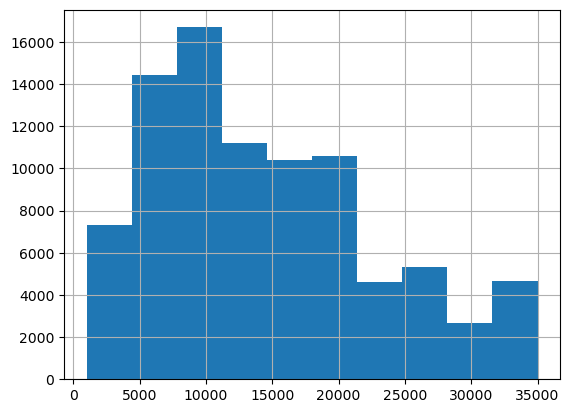

In [14]:
df_filtered['loan_amnt'].hist()

In [15]:
q1 = df_filtered['loan_amnt'].quantile(0.25)
q3 = df_filtered['loan_amnt'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound =  q3 + (1.5 * iqr)

print(upper_bound)

38150.0


### The upper bound is 38150.0 which tells us that the values 30k-35k are not statistical outliers and represent real-world loan amounts.
### Removing them would discard meaningful information for high-value loans. 

### EDA 
### annual_inc

<Axes: >

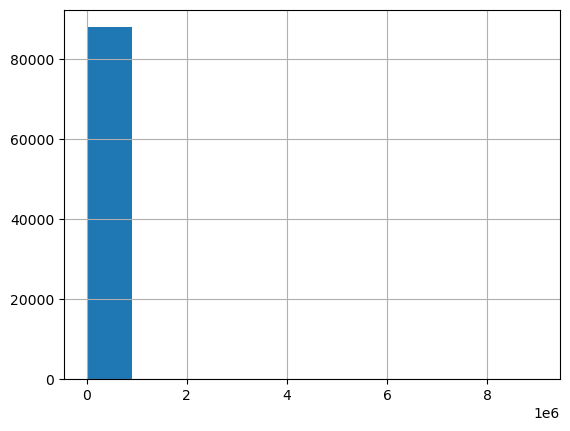

In [16]:
df_filtered['annual_inc'].hist()

### EDA for annual_inc
### The annual_inc feature is highly right-skewed.

### Most values are concentrated in the lower range, while a few very large values stretch the distribution and make it hard to visualize.

### To address this, we apply a log transformation to compress large values and better understand the distribution without removing data.

In [17]:
df_filtered['log_annual_inc'] = np.log1p(df_filtered['annual_inc'])

<Axes: >

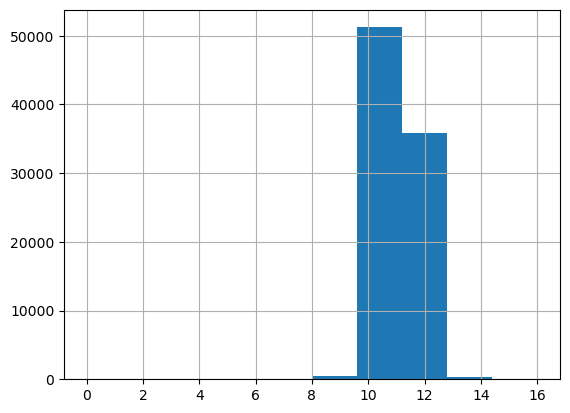

In [18]:
df_filtered['log_annual_inc'].hist()

### EDA
### instalment

<Axes: >

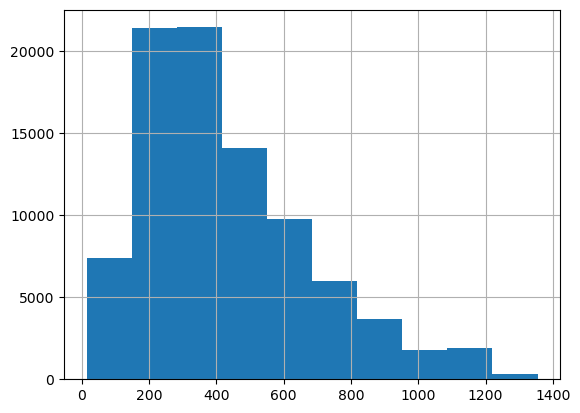

In [19]:
df_filtered['installment'].hist()

### EDA
### term

In [20]:
df_filtered['term'].value_counts()

term
36 months    67919
60 months    19973
Name: count, dtype: int64

### EDA
### int_rate

<Axes: >

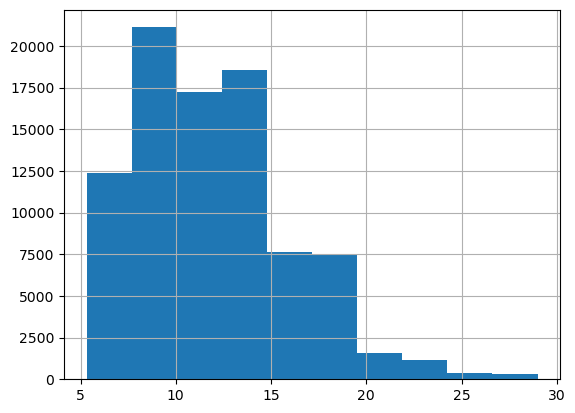

In [21]:
df_filtered['int_rate'].hist()

In [22]:
missing_values = df_filtered.isnull().sum()
missing_values[missing_values > 0]

member_id                87892
emp_title                 5650
emp_length                5629
desc                     87885
title                      118
                         ...  
settlement_status        84972
settlement_date          84972
settlement_amount        84972
settlement_percentage    84972
settlement_term          84972
Length: 71, dtype: int64

In [23]:
df_filtered.dtypes

id                         int64
member_id                float64
loan_amnt                float64
funded_amnt              float64
funded_amnt_inv          float64
                          ...   
settlement_amount        float64
settlement_percentage    float64
settlement_term          float64
is_default                 int64
log_annual_inc           float64
Length: 145, dtype: object

In [24]:
missing_percentage = (missing_values / df_filtered.shape[0]) * 100
print(missing_percentage)

id                         0.000000
member_id                100.000000
loan_amnt                  0.000000
funded_amnt                0.000000
funded_amnt_inv            0.000000
                            ...    
settlement_amount         96.677741
settlement_percentage     96.677741
settlement_term           96.677741
is_default                 0.000000
log_annual_inc             0.000000
Length: 145, dtype: float64


In [25]:
high_missing = missing_percentage[missing_percentage > 70]
high_missing.shape

(55,)

In [26]:
cols_to_drop = high_missing.index

df_filtered = df_filtered.drop(columns=cols_to_drop)

In [27]:
df_filtered.shape

(87892, 90)

In [28]:
df_filtered['term']  = df['term']
df_filtered['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [29]:
df_filtered['term'] = df_filtered['term'].str.strip()
df_filtered['term'].unique()



array(['36 months', '60 months'], dtype=object)

In [30]:
term_mapping = {
    '36 months' : 0,
    '60 months' : 1
}

df_filtered['term'] = df_filtered['term'].map(term_mapping)

df_filtered['term'].unique()

array([0, 1])

In [31]:
df_filtered['grade'].unique()

array(['C', 'B', 'F', 'A', 'E', 'D', 'G'], dtype=object)

In [32]:
df_filtered['grade'] = df['grade']


In [33]:
grade_mapping = {
    'A' : 0,
    'B' : 1,
    'C' : 2,
    'D' : 3,
    'E' : 4,
    'F' : 5,
    'G' : 6
}

df_filtered['grade'] = df_filtered['grade'].map(grade_mapping)

df_filtered['grade'].unique()

array([2, 1, 5, 0, 4, 3, 6])

In [34]:
df_filtered['sub_grade'].unique()

array(['C4', 'C1', 'B4', 'F1', 'C3', 'B2', 'B1', 'A2', 'B5', 'C2', 'E2',
       'A4', 'E3', 'C5', 'A1', 'D4', 'F3', 'D1', 'B3', 'D3', 'D5', 'A5',
       'F2', 'E4', 'D2', 'E1', 'F5', 'E5', 'A3', 'G2', 'G1', 'G3', 'G4',
       'F4', 'G5'], dtype=object)

In [35]:
sub_grades = df_filtered['sub_grade'].unique()

sorted_sub_grades = sorted(sub_grades)

sub_grade_mapping = {}

for index,value in enumerate(sorted_sub_grades):
    sub_grade_mapping[value] = index

print(sub_grade_mapping)

{'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'B1': 5, 'B2': 6, 'B3': 7, 'B4': 8, 'B5': 9, 'C1': 10, 'C2': 11, 'C3': 12, 'C4': 13, 'C5': 14, 'D1': 15, 'D2': 16, 'D3': 17, 'D4': 18, 'D5': 19, 'E1': 20, 'E2': 21, 'E3': 22, 'E4': 23, 'E5': 24, 'F1': 25, 'F2': 26, 'F3': 27, 'F4': 28, 'F5': 29, 'G1': 30, 'G2': 31, 'G3': 32, 'G4': 33, 'G5': 34}


In [36]:
df_filtered['sub_grade'] = df_filtered['sub_grade'].map(sub_grade_mapping)



In [37]:
df_filtered['sub_grade'].unique()

array([13, 10,  8, 25, 12,  6,  5,  1,  9, 11, 21,  3, 22, 14,  0, 18, 27,
       15,  7, 17, 19,  4, 26, 23, 16, 20, 29, 24,  2, 31, 30, 32, 33, 28,
       34])

In [38]:
df_filtered = df_filtered.drop(columns = 'grade')

In [39]:
df_filtered.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'recoveries',
       'collection_recovery_fee', 'last_credit_pull_d', 'last_fico_range_high',
       'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal',
       'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt',
       'mo_sin_old_il_acct', 'mo_sin_ol

In [40]:
df_filtered['home_ownership'].unique()

array(['MORTGAGE', 'RENT', 'OWN', 'ANY'], dtype=object)

In [41]:
home_ownership_encoded = pd.get_dummies(df_filtered['home_ownership'], drop_first=True)

home_ownership_encoded.head()

,MORTGAGE,OWN,RENT
0,True,False,False
1,True,False,False
2,True,False,False
4,True,False,False
5,False,False,True


In [42]:
df_filtered = pd.concat([df_filtered, home_ownership_encoded], axis=1)


In [43]:
df_filtered = df_filtered.drop(columns='home_ownership')

In [44]:
df_filtered.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_title,emp_length,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,recoveries,collection_recovery_fee,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,is_default,log_annual_inc,MORTGAGE,OWN,RENT
0,68407277,3600.0,3600.0,3600.0,0,13.99,123.03,13,leadman,10+ years,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,7.0,0.0,2765.0,29.7,13.0,w,0.0,0.0,0.0,0.0,Mar-2019,564.0,560.0,0.0,1.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0,10.915107,True,False,False
1,68355089,24700.0,24700.0,24700.0,0,11.99,820.28,10,Engineer,10+ years,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,22.0,0.0,21470.0,19.2,38.0,w,0.0,0.0,0.0,0.0,Mar-2019,699.0,695.0,0.0,1.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0,11.082158,True,False,False
2,68341763,20000.0,20000.0,20000.0,1,10.78,432.66,8,truck driver,10+ years,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,6.0,0.0,7869.0,56.2,18.0,w,0.0,0.0,0.0,0.0,Mar-2019,704.0,700.0,0.0,1.0,Joint App,0.0,0.0,189699.0,14000.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,10.0,NaN,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0,11.050906,True,False,False
4,68476807,10400.0,10400.0,10400.0,1,22.45,289.91,25,Contract Specialist,3 years,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,12.0,0.0,21929.0,64.5,35.0,w,0.0,0.0,0.0,0.0,Mar-2018,704.0,700.0,0.0,1.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0,11.556311,True,False,False
5,68426831,11950.0,11950.0,11950.0,0,13.44,405.18,12,Veterinary Tecnician,4 years,34000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,300xx,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,NaN,5.0,0.0,8822.0,68.4,6.0,w,0.0,0.0,0.0,0.0,May-2017,759.0,755.0,0.0,1.0,Individual,0.0,0.0,12798.0,12900.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.

In [45]:
print(df_filtered['purpose'].unique())

['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy']


In [46]:
df_filtered['purpose'].nunique()

12

In [47]:
purpose_encoded = pd.get_dummies(df_filtered['purpose'], drop_first=True)

purpose_encoded.head()

,credit_card,debt_consolidation,home_improvement,house,major_purchase,medical,moving,other,renewable_energy,small_business,vacation
0,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False
2,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False
5,False,True,False,False,False,False,False,False,False,False,False


In [48]:
df_filtered = pd.concat([df_filtered, purpose_encoded], axis=1)

In [49]:
df_filtered = df_filtered.drop(columns='purpose')

In [50]:
df_filtered.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_title,emp_length,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,recoveries,collection_recovery_fee,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,is_default,log_annual_inc,MORTGAGE,OWN,RENT,credit_card,debt_consolidation,home_improvement,house,major_purchase,medical,moving,other,renewable_energy,small_business,vacation
0,68407277,3600.0,3600.0,3600.0,0,13.99,123.03,13,leadman,10+ years,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,7.0,0.0,2765.0,29.7,13.0,w,0.0,0.0,0.0,0.0,Mar-2019,564.0,560.0,0.0,1.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0,10.915107,True,False,False,False,True,False,False,False,False,False,False,False,False,False
1,68355089,24700.0,24700.0,24700.0,0,11.99,820.28,10,Engineer,10+ years,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,22.0,0.0,21470.0,19.2,38.0,w,0.0,0.0,0.0,0.0,Mar-2019,699.0,695.0,0.0,1.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0,11.082158,True,False,False,False,False,False,False,False,False,False,False,False,True,False
2,68341763,20000.0,20000.0,20000.0,1,10.78,432.66,8,truck driver,10+ years,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,605xx,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,6.0,0.0,7869.0,56.2,18.0,w,0.0,0.0,0.0,0.0,Mar-2019,704.0,700.0,0.0,1.0,Joint App,0.0,0.0,189699.0,14000.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,10.0,NaN,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0,11.050906,True,False,False,False,False,True,False,False,False,False,False,False,False,False
4,68476807,10400.0,10400.0,10400.0,1,22.45,289.91,25,Contract Specialist,3 years,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,12.0,0.0,21929.0,64.5,35.0,w,0.0,0.0,0.0,0.0,Mar-2018,704.0,700.0,0.0,1.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0,11.556311,True,False,False,False,False,False,False,True,False,False,False,False,False,False
5,68426831,11950.0,11950.0,11950.0,0,13.44,405.18,12,Veterinary Tecnician,4 years,34000.0,Source Verif

In [51]:
df_filtered.shape

(87892, 101)